# Image Processing Notebook: Plot the H Cross-Section (from Transmission)


This notebook takes the processed transmission imagesand plot the H Cross-sections from specific ROIs

## Initial Settings

### Import Libraries

In [1]:
import sys
sys.path.append(r'..\01_Functions')
from step_functions import *
from dict_functions import *
from proc_functions import *
from img_functions import *
from plotting_cs import *
from cross_sections import *
import seaborn as sns
%matplotlib inline
pd.set_option('display.max_rows', 20)

### Provide Directories

#### Provide the directory for transmission images

In [2]:
# %load select_directory('ref_dir')
ref_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_empty_ref02"

In [3]:
src_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\01_Transmission_results\000_exp2000\00_LP30_deg"

#### Provide the Spectra.txt file from any of the experiments. 
These are the neutron arrival times the MCP detected

In [4]:
# %load select_file('spectra_file')
spectra_file = r"J:\700 Campaigns - internal\2022\PSI22_04NI\Raw_images\exp2000\exp2200_LP40_deg\02_pos00\IMAT00018918_02_pos00_001_Spectra.txt"

#### Provide the directory for saving results

In [5]:
# %load select_directory('dst_dir')
dst_dir = r"J:\700 Campaigns - internal\2022\PSI22_04NI\00_Processed\02_Cross_sections_results\000_exp1000"

### Read the directory and extract values from images
You can specify a single folder but if you want all the folders in the `src_dir`, leave `proc_folder=[]`.

In [6]:
src_dict = read_saved_dict (src_dir, proc_folder = [])
ref_dict = read_saved_dict (ref_dir, proc_folder = [])

Reading Images: 100%|████████████████████████████| 5/5 [00:00<00:00,  8.31it/s]


#### Extract an averaged image for each key
For each `proc_folder` (acquisition), an averaged image will be extracted

In [7]:
avg_imgs = []
for key, value in ref_dict.items():
    img =  avg_frames_dict (value, output_type = 'img', start_img = 15, end_slice = 20)
    avg_imgs.append(img[0])

#### Select the ROIs
For simplicity handling the names, `ROIs_` before the name of the `proc_folder` is required

In [8]:
# %load select_multiple_rois(proc_folder[0], avg_images[0], cmap = 'flag')

# from each chip region LP30 degraded
ROIs_02_pos00 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]
ROIs_04_pos01 = [[146, 35, 78, 69], [33, 35, 78, 69], [32, 154, 78, 38], [145, 152, 78, 40]] #
ROIs_06_pos02 = [[146, 35, 78, 69], [33, 35, 78, 69],                    [145, 152, 78, 69]]
ROIs_08_pos03 = [                   [33, 35, 78, 69], [33, 154, 78, 69], [145, 152, 78, 69]]
ROIs_10_pos04 = [                   [33, 35, 78, 69], [32, 154, 78, 69], [145, 152, 78, 69]]

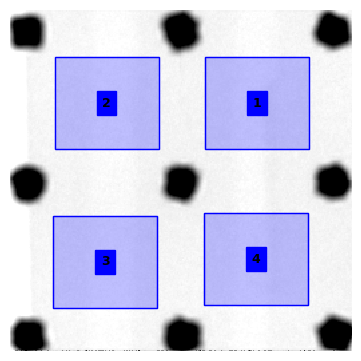

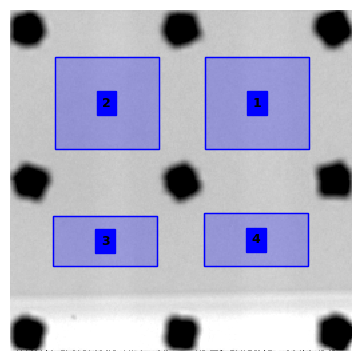

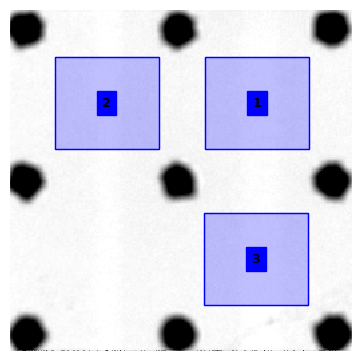

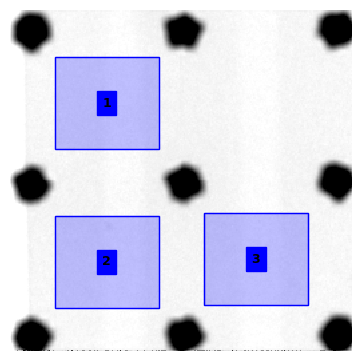

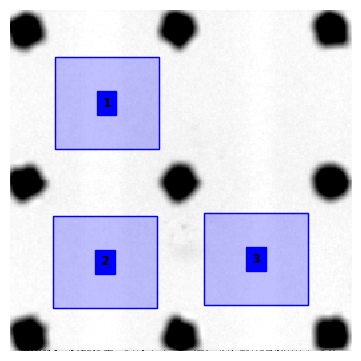

In [9]:
show_img(avg_imgs[0], dr = [(ROIs_02_pos00, 'blue')], cmap='gray', nrows=3, ncols=2, index=1)
show_img(avg_imgs[1], dr = [(ROIs_04_pos01, 'blue')], cmap='gray', nrows=3, ncols=2, index=2)
show_img(avg_imgs[2], dr = [(ROIs_06_pos02, 'blue')], cmap='gray', nrows=3, ncols=2, index=3)
show_img(avg_imgs[3], dr = [(ROIs_08_pos03, 'blue')], cmap='gray', nrows=3, ncols=2, index=4)
show_img(avg_imgs[4], dr = [(ROIs_10_pos04, 'blue')], cmap='gray', nrows=3, ncols=2, index=5)

#### Create a dictionary of the ROIs

In [10]:
rois_dict = {}
for name in ref_dict.keys():
    rois_name = 'ROIs_'+ name
    for rois in [rois_name]:
        rois_dict[rois] = eval(rois)

### Extract the values

In [11]:
ref_vals = get_roi_values (ref_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [12]:
img_vals = get_roi_values (src_dict, rois_dict, spectra_file, save_path = dst_dir, binning = 20, 
                                 flight_path = 56, start_slice = 0, name_xlsx = 'Roi_values_auto.xlsx', 
                                 save_results = False)

In [13]:
data_wvl = img_vals['Wavelength [Å]']

ref_vals = ref_vals.loc[2:36]
ref_vals = ref_vals.reset_index(drop=True)

img_vals = img_vals.loc[2:36]
img_vals = img_vals.reset_index(drop=True)

In [14]:
trans_rois = prepare_trans_data(img_vals, data_ref = ref_vals, data_output = 'transmission')

In [15]:
trans_rois

,Wavelength [Å],Transmission_02_pos00_roi_1,Transmission_02_pos00_roi_2,Transmission_02_pos00_roi_3,Transmission_02_pos00_roi_4,Transmission_04_pos01_roi_1,Transmission_04_pos01_roi_2,Transmission_04_pos01_roi_3,Transmission_04_pos01_roi_4,Transmission_06_pos02_roi_1,Transmission_06_pos02_roi_2,Transmission_06_pos02_roi_3,Transmission_08_pos03_roi_1,Transmission_08_pos03_roi_2,Transmission_08_pos03_roi_3,Transmission_10_pos04_roi_1,Transmission_10_pos04_roi_2,Transmission_10_pos04_roi_3
0,1.279359,0.880558,0.879037,0.881232,0.878568,0.885357,0.881071,0.881288,0.876640,0.881837,0.881130,0.880870,0.877309,0.882959,0.882446,0.882782,0.884485,0.880379
1,1.531952,0.870603,0.865200,0.868013,0.870855,0.870049,0.870934,0.861353,0.863938,0.872488,0.874899,0.872570,0.869059,0.874421,0.870683,0.869342,0.872280,0.866373
2,1.776463,0.860567,0.854351,0.858495,0.861632,0.863510,0.862431,0.854722,0.857634,0.862452,0.864962,0.864681,0.856846,0.863426,0.860072,0.862633,0.863771,0.857223
3,2.032233,0.853067,0.847292,0.851298,0.856740,0.858244,0.857857,0.849777,0.851210,0.855732,0.855932,0.858550,0.850928,0.858656,0.856505,0.856053,0.858460,0.851720
4,2.304880,0.847265,0.841232,0.846409,0.849646,0.851469,0.850688,0.843109,0.843904,0.850245,0.850781,0.853832,0.846218,0.854452,0.850947,0.848572,0.850406,0.842491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.806118,0.726269,0.705603,0.720455,0.741741,0.741116,0.746826,0.706961,0.714245,0.739268,0.739061,0.739400,0.715477,0.733288,0.735780,0.732511,0.722948,0.708907
31,9.039954,0.725386,0.707743,0.714258,0.742279,0.735740,0.751732,0.717818,0.712315,0.734017,0.741870,0.744266,0.709802,0.727462,0.728234,0.730194,0.745131,0.723233
32,9.271439,0.727493,0.691084,0.718203,0.744260,0.740874,0.739440,0.697907,0.713222,0.728905,0.728024,0.743777,0.711732,0.717471,0.728271,0.723692,0.728054,0.709695
33,9.525303,0.724211,0.691981,0.706294,0.735424,0.727531,0.734490,0.707653,0.696421,0.720698,0.725639,0.726457,0.724146,0.735045,0.739231,0.728052,0.728712,0.707269


### Get the transmission table
If the images given before are transmission, leave empty the data_ref in the `prepare_trans_data` function. 
If not, run the previous line but with the reference images directory.

Depending on the **data_output** chosen ('transmission'. 'optical density', 'total cs', or 'h cs'). if the requested data is `total cs` or `h cs`, a dictionary of compounds is required. This is basically a list of the material expected **in oder** from the ROIs given before.

The  full dictionary of cross-sections is located at the top of the `plotting_cs` function. In the notebook, we are using only those that are required to avoid clogging the information.

### H cross section parameters

In [16]:
thickness = 0.061

ec = {'abbv': 'EC', 'composition' : {'C':3.0, 'H':4.0, 'O':3.0},'density':1.32, 'thickness': thickness}
dmc = {'abbv': 'DMC','composition' : {'C':3.0, 'H':6.0, 'O':3.0}, 'density':1.07, 'thickness': thickness}
dec = {'abbv': 'DEC','composition' : {'C':5.0, 'H':10.0, 'O':3.0}, 'density':0.975, 'thickness': thickness}
lipf6 = {'abbv': 'LiPF6','composition' : {'LI':1.0, 'P':1.0, 'F':6.0}, 'density':1.5, 'thickness': thickness}
ec_dmc_11v = {'abbv': 'EC_DMC (1:1v)','molecules' : [ec,0.5,dmc,0.5], 'density':1.28, 'thickness': thickness}
ec_dec_11v = {'abbv': 'EC_DEC (1:1v)','molecules' : [ec,0.5,dec,0.5], 'density':1.1785, 'thickness': thickness}
#lp30 = {'abbv': 'LP30','molecules' : [ec, 0.406359477,dmc, 0.501683056, lipf6, 0.091957467], 'density':1.2795, 'thickness': thickness}
#lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.2635, 'thickness': thickness}

lp30 = {'abbv': 'LP30','molecules' : [ec, 0.446003162,dmc, 0.446003162, lipf6, 0.107993676], 'density':1.2284, 'thickness': thickness}
lp40 = {'abbv': 'LP40','molecules' : [ec, 0.447925137,dec, 0.447925137, lipf6, 0.104149725], 'density':1.1847, 'thickness': thickness}



## exp1000 -> LP30


In [17]:
compounds_dict = [lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30,
                 lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30, lp30]

### Get the cross sections
Function to get the cross sections, the requested_cs is a list of the desired cross-sections options are ['total_cs','h_cs','li_cs']

In [18]:
res_data = prepare_trans_data(trans_rois, data_output = 'h cs', compounds_dict = compounds_dict)

Data_imgs variable taken as transmission images


**it was determined that an interpolation via Savgol of 5,2 does not affect the outcome but improves the data visualization. Therefore, it was kept**

In [ ]:
#save_DF (dst_dir, res_data, df_name = '00_LP30_H_CS.xlsx', sheet_name = 'lp30_deg_savgol_52', mode = 'a')

In [19]:
res_data = dataframe_to_savgol(res_data, 5, 2)

In [ ]:
save_DF (dst_dir, res_data, df_name = '00_LP30_H_CS.xlsx', sheet_name = 'degrad_061', mode = 'a')

In [20]:
    # position column name extraction
pos00 = [column for column in res_data if 'pos00' in column]
pos01 = [column for column in res_data if 'pos01' in column]
pos02 = [column for column in res_data if 'pos02' in column]
pos03 = [column for column in res_data if 'pos03' in column]
pos04 = [column for column in res_data if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_dat = pd.concat([data_wvl, res_data[pos00]], axis = 1)
cs_pos01_dat = pd.concat([data_wvl, res_data[pos01]], axis = 1)
cs_pos02_dat = pd.concat([data_wvl, res_data[pos02]], axis = 1)
cs_pos03_dat = pd.concat([data_wvl, res_data[pos03]], axis = 1)
cs_pos04_dat = pd.concat([data_wvl, res_data[pos04]], axis = 1)

avg_vals_dat = pd.DataFrame(data_wvl)
avg_vals_dat ['pos00'] = cs_pos00_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos01'] = cs_pos01_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos02'] = cs_pos02_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos03'] = cs_pos03_dat.iloc[:,1:].mean(axis=1)
avg_vals_dat ['pos04'] = cs_pos04_dat.iloc[:,1:].mean(axis=1)

In [21]:
cs_pos00_dat=cs_pos00_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos01_dat=cs_pos01_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos02_dat=cs_pos02_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos03_dat=cs_pos03_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
cs_pos04_dat=cs_pos04_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')
avg_vals_dat=avg_vals_dat.melt('Wavelength [Å]', var_name='val', value_name='cross-section [barns]')

In [22]:
#sns.relplot(data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val', 
#            kind = 'line', legend = 'brief', height=6, aspect=1.2)

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='cross-section [barns]'>

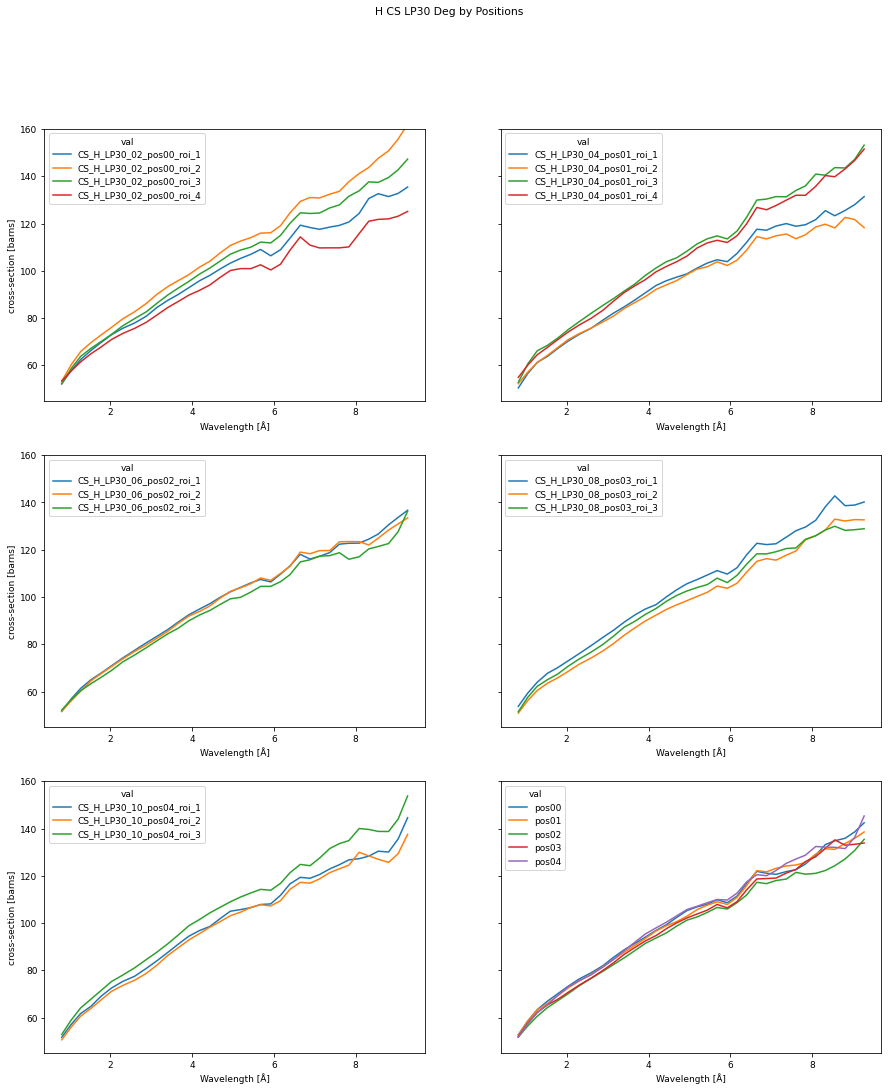

In [23]:
fig0, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig0.suptitle('H CS LP30 Deg by Positions')
plt.ylim([45,160])
sns.lineplot(ax = ax[0,0], data = cs_pos00_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_dat, x = 'Wavelength [Å]', y = 'cross-section [barns]', hue = 'val')

### Normalize by 3A

In [24]:
res_data_PEnorm = normalize_to_PE(res_data)

In [25]:
res_data_PEn3Anorm = normalize_to_range(res_data_PEnorm, idx_range = [3,4])

In [26]:
res_data_PEn3Anorm = dataframe_to_savgol(res_data_PEn3Anorm, 5, 1)

In [27]:
    # position column name extraction
pos00 = [column for column in res_data_PEn3Anorm if 'pos00' in column]
pos01 = [column for column in res_data_PEn3Anorm if 'pos01' in column]
pos02 = [column for column in res_data_PEn3Anorm if 'pos02' in column]
pos03 = [column for column in res_data_PEn3Anorm if 'pos03' in column]
pos04 = [column for column in res_data_PEn3Anorm if 'pos04' in column]
    # recalling the data with the specified columns and the wavelength column up front
cs_pos00_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos00]], axis = 1)
cs_pos01_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos01]], axis = 1)
cs_pos02_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos02]], axis = 1)
cs_pos03_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos03]], axis = 1)
cs_pos04_norm = pd.concat([data_wvl, res_data_PEn3Anorm[pos04]], axis = 1)

avg_vals_norm = pd.DataFrame(data_wvl)
avg_vals_norm ['pos00'] = cs_pos00_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos01'] = cs_pos01_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos02'] = cs_pos02_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos03'] = cs_pos03_norm.iloc[:,1:].mean(axis=1)
avg_vals_norm ['pos04'] = cs_pos04_norm.iloc[:,1:].mean(axis=1)

In [28]:
#avg_vals = dataframe_to_savgol(avg_vals, 15, 1)

In [29]:
cs_pos00_norm=cs_pos00_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos01_norm=cs_pos01_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos02_norm=cs_pos02_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos03_norm=cs_pos03_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
cs_pos04_norm=cs_pos04_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')
avg_vals_norm=avg_vals_norm.melt('Wavelength [Å]', var_name='val', value_name='Normalized cross-section [-]')

<AxesSubplot:xlabel='Wavelength [Å]', ylabel='Normalized cross-section [-]'>

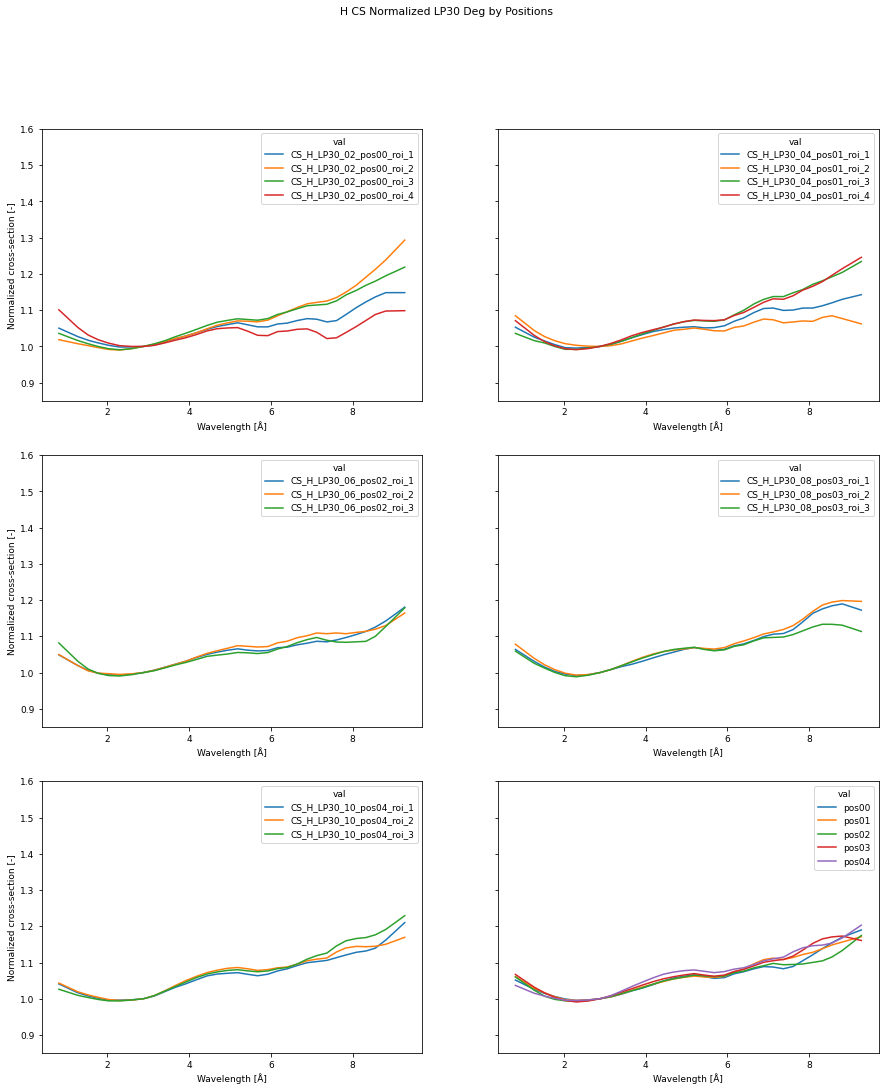

In [30]:
fig1, ax = plt.subplots(3,2, figsize = (15,17), sharey = True)
fig1.suptitle('H CS Normalized LP30 Deg by Positions')
#ax[0,0].set_title('Pos00')
plt.ylim([0.85,1.6])
sns.lineplot(ax = ax[0,0], data = cs_pos00_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[0,1], data = cs_pos01_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,0], data = cs_pos02_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[1,1], data = cs_pos03_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,0], data = cs_pos04_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')
sns.lineplot(ax = ax[2,1], data = avg_vals_norm, x = 'Wavelength [Å]', y = 'Normalized cross-section [-]', hue = 'val')

In [31]:
res_data_PEn3Anorm

,Wavelength [Å],CS_H_LP30_02_pos00_roi_1,CS_H_LP30_02_pos00_roi_2,CS_H_LP30_02_pos00_roi_3,CS_H_LP30_02_pos00_roi_4,CS_H_LP30_04_pos01_roi_1,CS_H_LP30_04_pos01_roi_2,CS_H_LP30_04_pos01_roi_3,CS_H_LP30_04_pos01_roi_4,CS_H_LP30_06_pos02_roi_1,CS_H_LP30_06_pos02_roi_2,CS_H_LP30_06_pos02_roi_3,CS_H_LP30_08_pos03_roi_1,CS_H_LP30_08_pos03_roi_2,CS_H_LP30_08_pos03_roi_3,CS_H_LP30_10_pos04_roi_1,CS_H_LP30_10_pos04_roi_2,CS_H_LP30_10_pos04_roi_3
0,1.273682,1.050431,1.018644,1.036111,1.101098,1.052918,1.084763,1.035953,1.071008,1.048926,1.049807,1.081691,1.063900,1.078225,1.059067,1.040906,1.043370,1.026251
1,1.529439,1.038792,1.013058,1.026198,1.076770,1.039196,1.064195,1.025911,1.050661,1.034205,1.034607,1.056525,1.047317,1.058598,1.042266,1.028737,1.031325,1.017812
2,1.785196,1.027154,1.007472,1.016285,1.052441,1.025475,1.043627,1.015868,1.030314,1.019484,1.019407,1.031359,1.030734,1.038972,1.025465,1.016567,1.019281,1.009374
3,2.048178,1.017019,1.002209,1.007394,1.031525,1.014925,1.027054,1.009452,1.013103,1.006260,1.004801,1.009747,1.015031,1.021399,1.012203,1.007698,1.010581,1.003384
4,2.318891,1.009770,0.996820,0.999805,1.018554,1.005078,1.015853,0.999971,1.001598,0.998267,0.998621,0.997985,1.003349,1.008223,1.000497,1.001684,1.003912,0.998048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,8.799547,1.122763,1.191141,1.168663,1.071615,1.112276,1.080059,1.181262,1.178868,1.113678,1.113817,1.086236,1.175818,1.186429,1.133351,1.131775,1.143588,1.168843
31,9.038885,1.136666,1.212870,1.180155,1.088170,1.120308,1.084701,1.192245,1.196165,1.125600,1.119739,1.100141,1.184231,1.194491,1.133215,1.139719,1.144855,1.176445
32,9.279254,1.148386,1.238644,1.194877,1.097649,1.130035,1.076934,1.204331,1.214573,1.142324,1.129818,1.127120,1.189596,1.198776,1.130791,1.161924,1.150304,1.191168
33,9.519003,1.148419,1.265991,1.206853,1.098165,1.136422,1.069609,1.219311,1.230238,1.161468,1.147099,1.152919,1.181001,1.197618,1.122137,1.186041,1.159962,1.210189
